NLP Text Cleaning & Word Cloud Analyzer

Basic Importing

In [ ]:
import re ## working with patterns in text(finding url,emails)
import html ### For the Html File
import unicodedata ## for handling special Characters and emojis
from  collections import Counter ## For the counting words
from pprint import pprint ## for the pretty Prints

In [ ]:
## normal  print like {'has_digits':'False','has_emails':'True','length':135}
## pprint:{
    # 'has_digit':'False',
    # 'has_emails':'True',
    # 'length' :135
# }
## nltk and spacy are the popular nlp libaries checking install or not not
try:
  import nltk
  nltk_available = True
except Exception:
  nltk_available = False
try:
  import spacy
  spacy_available = True
except Exception:
  spacy_available = False

Sample Text in the Different Types

In [ ]:
sample_texts = {
    "social_text": """
    OMG!!! I loooove momos soooo much 😍😍😍
    Visit https://foodmandu.com NOW!!!
    Contact me at ramesh123@gmail.com
    #Kathmandu #Food @foodmandu
    """,

    "html_text": """
    <html>
        <body>
            <h1>Welcome to Tribhuvan University</h1>
            <p>This is <b>best university</b>!!!</p>
            <a href="https://tu.edu.np">Click here</a>
        </body>
    </html>
    """,

    "finance_text": """
    NABIL bank gained 5.30% today. Price moved from Rs. 450.00 to Rs. 473.85.
    Revenue in FY 2025/26 increased by 15.2%.
    Contact info.nabil@nabilbank.com for details.
    """,

    "mixed_text": """
    Kathmandu is ekdamm ramro city!!! ma hajur sanga janchu :)
    Yo momo ekदम mito cha bro.
    Call me at +977-9801234567 after 6:30 PM.
    """,

    "noisy_text": """
    Thissss is a    very very very baaad day!!!!
    plsss hellpp meeee.\n\nI canttt do thissss!!!
    so    many   spaces    here bro!!!
    """,

    "entity_text": """
    Elon Musk visited Kathmandu on April 01, 2026.
    Nepal Rastra Bank announced new interest rate policy.
    Ncell and Nepal Telecom both launched new offers today.
    """
}

for name, text in sample_texts.items():
    print(f"--- {name} ---")
    print(text.strip()) ## it removes the whitespace
    print()## it display with clean wise

--- social_text ---
OMG!!! I loooove momos soooo much 😍😍😍
    Visit https://foodmandu.com NOW!!!
    Contact me at ramesh123@gmail.com
    #Kathmandu #Food @foodmandu

--- html_text ---
<html>
        <body>
            <h1>Welcome to Tribhuvan University</h1>
            <p>This is <b>best university</b>!!!</p>
            <a href="https://tu.edu.np">Click here</a>
        </body>
    </html>

--- finance_text ---
NABIL bank gained 5.30% today. Price moved from Rs. 450.00 to Rs. 473.85.
    Revenue in FY 2025/26 increased by 15.2%.
    Contact info.nabil@nabilbank.com for details.

--- mixed_text ---
Kathmandu is ekdamm ramro city!!! ma hajur sanga janchu :)
    Yo momo ekदम mito cha bro.
    Call me at +977-9801234567 after 6:30 PM.

--- noisy_text ---
Thissss is a    very very very baaad day!!!!
    plsss hellpp meeee.

I canttt do thissss!!!
    so    many   spaces    here bro!!!

--- entity_text ---
Elon Musk visited Kathmandu on April 01, 2026.
    Nepal Rastra Bank announced new

Text Inspector

In [ ]:
## re.search to find the patterns like emails, urls, hastags inside text
def inspect_text(text):
    report = {
        "length": len(text),
        "has_uppercase": bool(re.search(r"[A-Z]", text)),
        "has_lowercase": bool(re.search(r"[a-z]", text)),
        "has_extra_spaces": "  " in text,
        "has_new_lines": "\n" in text,
        "has_tabs": "\t" in text,
        "has_urls": bool(re.search(r"https?://\S+|www\.\S+", text)),
        "has_emails": bool(re.search(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", text)),
        "has_hashtags": bool(re.search(r"#\w+", text)),
        "has_mentions": bool(re.search(r"@\w+", text)),
        "has_html_tags": bool(re.search(r"<[^>]+>", text)),
        "has_repeated_letters": bool(re.search(r"(.)\1{2,}", text)),
        "has_digits": bool(re.search(r"\d", text)),
        "has_emojis_or_non_ascii": any(ord(ch) > 127 for ch in text),
        "punctuation_count": len(re.findall(r"[^\w\s]", text)),
    }
    return report

for name, text in sample_texts.items():
    print(name)
    pprint(inspect_text(text))
    print()

social_text
{'has_digits': True,
 'has_emails': True,
 'has_emojis_or_non_ascii': True,
 'has_extra_spaces': True,
 'has_hashtags': True,
 'has_html_tags': False,
 'has_lowercase': True,
 'has_mentions': True,
 'has_new_lines': True,
 'has_repeated_letters': True,
 'has_tabs': False,
 'has_uppercase': True,
 'has_urls': True,
 'length': 156,
 'punctuation_count': 18}

html_text
{'has_digits': True,
 'has_emails': False,
 'has_emojis_or_non_ascii': False,
 'has_extra_spaces': True,
 'has_hashtags': False,
 'has_html_tags': True,
 'has_lowercase': True,
 'has_mentions': False,
 'has_new_lines': True,
 'has_repeated_letters': True,
 'has_tabs': False,
 'has_uppercase': True,
 'has_urls': True,
 'length': 220,
 'punctuation_count': 41}

finance_text
{'has_digits': True,
 'has_emails': True,
 'has_emojis_or_non_ascii': False,
 'has_extra_spaces': True,
 'has_hashtags': False,
 'has_html_tags': False,
 'has_lowercase': True,
 'has_mentions': True,
 'has_new_lines': True,
 'has_repeated_lette

Basic Normalization

In [ ]:
def to_lowercase(text):
    return text.lower()

def strip_whitespace(text):
    return text.strip()

def remove_extra_spaces(text):
    return re.sub(r"\s+", " ", text).strip()

def remove_tabs_and_newlines(text):
    return text.replace("\n", " ").replace("\t", " ")

def normalize_unicode(text):
    return unicodedata.normalize("NFKC", text)

def remove_html_tags(text):
    return re.sub(r"<[^>]+>", " ", text)

def remove_urls(text):
    return re.sub(r"https?://\S+|www\.\S+", " ", text)

def remove_emails(text):
    return re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " ", text)

def remove_hashtags_mentions(text):
    text = re.sub(r"#\w+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    return text

def remove_special_characters(text):
    return re.sub(r"[^a-zA-Z0-9\s]", " ", text)

def show_step(step_name, before, after):
    print(f"\n--- {step_name} ---")
    print("BEFORE:", repr(before))
    print("AFTER :", repr(after))

In [ ]:
text = sample_texts["social_text"]

step1 = to_lowercase(text)
show_step("1. Lowercase conversion", text, step1)

step2 = strip_whitespace(step1)
show_step("2. Strip leading/trailing spaces", step1, step2)

step3 = remove_extra_spaces(step2)
show_step("3. Remove extra spaces", step2, step3)

step4 = remove_tabs_and_newlines(step3)
show_step("4. Remove tabs and new lines", step3, step4)

step5 = normalize_unicode(step4)
show_step("5. Unicode normalization", step4, step5)

step6 = remove_html_tags(step5)
show_step("6. Remove HTML tags", step5, step6)

step7 = remove_urls(step6)
show_step("7. Remove URLs", step6, step7)

step8 = remove_emails(step7)
show_step("8. Remove email addresses", step7, step8)

step9 = remove_hashtags_mentions(step8)
show_step("9. Remove hashtags / mentions", step8, step9)

step10 = remove_special_characters(step9)
show_step("10. Remove special characters", step9, step10)


--- 1. Lowercase conversion ---
BEFORE: '\n    OMG!!! I loooove momos soooo much 😍😍😍\n    Visit https://foodmandu.com NOW!!!\n    Contact me at ramesh123@gmail.com\n    #Kathmandu #Food @foodmandu\n    '
AFTER : '\n    omg!!! i loooove momos soooo much 😍😍😍\n    visit https://foodmandu.com now!!!\n    contact me at ramesh123@gmail.com\n    #kathmandu #food @foodmandu\n    '

--- 2. Strip leading/trailing spaces ---
BEFORE: '\n    omg!!! i loooove momos soooo much 😍😍😍\n    visit https://foodmandu.com now!!!\n    contact me at ramesh123@gmail.com\n    #kathmandu #food @foodmandu\n    '
AFTER : 'omg!!! i loooove momos soooo much 😍😍😍\n    visit https://foodmandu.com now!!!\n    contact me at ramesh123@gmail.com\n    #kathmandu #food @foodmandu'

--- 3. Remove extra spaces ---
BEFORE: 'omg!!! i loooove momos soooo much 😍😍😍\n    visit https://foodmandu.com now!!!\n    contact me at ramesh123@gmail.com\n    #kathmandu #food @foodmandu'
AFTER : 'omg!!! i loooove momos soooo much 😍😍😍 visit http

## Tokenization

In [ ]:
text = "Hello world! NLP is fun. This is the 3rd class."

print("Original text:")
print(text)

# Very simple word tokenization
simple_words = text.split()
print("\nSimple split tokenization:")
print(simple_words)

# Very simple sentence splitting
simple_sentences = re.split(r"[.!?]+", text)
simple_sentences = [s.strip() for s in simple_sentences if s.strip()]
print("\nSimple sentence tokenization:")
print(simple_sentences)

Original text:
Hello world! NLP is fun. This is the 3rd class.

Simple split tokenization:
['Hello', 'world!', 'NLP', 'is', 'fun.', 'This', 'is', 'the', '3rd', 'class.']

Simple sentence tokenization:
['Hello world', 'NLP is fun', 'This is the 3rd class']


Regax Based Tokenization

In [ ]:
text = "NABIL gained 3.45% today, isn't it amazing?"

word_tokens = re.findall(r"\b\w+\b", text)
print("Regex word tokens:")
print(word_tokens)

sentence_tokens = re.split(r"(?<=[.!?])\s+", text.strip())
print("\nRegex sentence tokens:")
print(sentence_tokens)

Regex word tokens:
['NABIL', 'gained', '3', '45', 'today', 'isn', 't', 'it', 'amazing']

Regex sentence tokens:
["NABIL gained 3.45% today, isn't it amazing?"]


NLTK Tokenization

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
if nltk_available:
    try:
        nltk.data.find("tokenizers/punkt")
    except LookupError:
        nltk.download("punkt")

    from nltk.tokenize import sent_tokenize, word_tokenize

    text = "Hello world! NLP is fun. I'm learning tokenization."
    print("Sentence tokens:")
    print(sent_tokenize(text))

    print("\nWord tokens:")
    print(word_tokenize(text))

else:
    print("NLTK is not installed, so this section is skipped.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Sentence tokens:
['Hello world!', 'NLP is fun.', "I'm learning tokenization."]

Word tokens:
['Hello', 'world', '!', 'NLP', 'is', 'fun', '.', 'I', "'m", 'learning', 'tokenization', '.']


 Punctuation and Symbol Handling

In [ ]:
examples = [
    "I can't do this.",
    "NABIL rose 3.45%.",
    "Price is Rs. 1,245.50.",
    "Use C++ for systems programming.",
    "The U.S. market moved up."
]

for ex in examples:
    print(ex)

I can't do this.
NABIL rose 3.45%.
Price is Rs. 1,245.50.
Use C++ for systems programming.
The U.S. market moved up.


In [ ]:
def remove_all_punctuation(text):
    return re.sub(r"[^\w\s]", "", text)

def keep_decimal_and_percent(text):
    return re.sub(r"[^\w\s.%]", "", text)

examples = [
    "I can't do this.",
    "NABIL rose 3.45%.",
    "Price is Rs. 1,245.50.",
    "C++ is powerful!"
]

for ex in examples:
    print("ORIGINAL :", ex)
    print("ALL REMOVED:", remove_all_punctuation(ex))
    print("KEEP . and %:", keep_decimal_and_percent(ex))
    print()

ORIGINAL : I can't do this.
ALL REMOVED: I cant do this
KEEP . and %: I cant do this.

ORIGINAL : NABIL rose 3.45%.
ALL REMOVED: NABIL rose 345
KEEP . and %: NABIL rose 3.45%.

ORIGINAL : Price is Rs. 1,245.50.
ALL REMOVED: Price is Rs 124550
KEEP . and %: Price is Rs. 1245.50.

ORIGINAL : C++ is powerful!
ALL REMOVED: C is powerful
KEEP . and %: C is powerful



Stop Word Removal

In [ ]:
basic_stopwords = {
    "the", "is", "am", "are", "a", "an", "in", "on", "at", "and", "of", "to", "this", "that"
}

def remove_stopwords(tokens, stopwords):
    return [token for token in tokens if token.lower() not in stopwords]

text = "This is a basic example of stop word removal in NLP."
tokens = re.findall(r"\b\w+\b", text.lower())

print("Original tokens:")
print(tokens)

clean_tokens = remove_stopwords(tokens, basic_stopwords)
print("\nAfter stop word removal:")
print(clean_tokens)

Original tokens:
['this', 'is', 'a', 'basic', 'example', 'of', 'stop', 'word', 'removal', 'in', 'nlp']

After stop word removal:
['basic', 'example', 'stop', 'word', 'removal', 'nlp']


In [ ]:
examples = [
    "This movie is not good.",
    "I do not recommend this stock.",
    "The contract is not valid.",
    "What is the price of NABIL?"
]

for ex in examples:
    tokens = re.findall(r"\b\w+\b", ex.lower())
    cleaned = remove_stopwords(tokens, basic_stopwords.union({"not", "do", "what"}))
    print("ORIGINAL:", ex)
    print("TOKENS  :", tokens)
    print("REMOVED :", cleaned)
    print()

ORIGINAL: This movie is not good.
TOKENS  : ['this', 'movie', 'is', 'not', 'good']
REMOVED : ['movie', 'good']

ORIGINAL: I do not recommend this stock.
TOKENS  : ['i', 'do', 'not', 'recommend', 'this', 'stock']
REMOVED : ['i', 'recommend', 'stock']

ORIGINAL: The contract is not valid.
TOKENS  : ['the', 'contract', 'is', 'not', 'valid']
REMOVED : ['contract', 'valid']

ORIGINAL: What is the price of NABIL?
TOKENS  : ['what', 'is', 'the', 'price', 'of', 'nabil']
REMOVED : ['price', 'nabil']



Handling Repeated and Noisy Text

In [ ]:
text = "This is sooooo good!!!!! I realllyyyyy love ittttt!!!"

def reduce_repeated_letters(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

def reduce_repeated_punctuation(text):
    return re.sub(r"([!?.}])\1{1,}", r"\1", text)

def remove_adjacent_duplicate_words(text):
    tokens = text.split()
    if not tokens:
        return text
    result = [tokens[0]]
    for token in tokens[1:]:
        if token.lower() != result[-1].lower():
            result.append(token)
    return " ".join(result)

step1 = reduce_repeated_letters(text)
step2 = reduce_repeated_punctuation(step1)
print("ORIGINAL:", text)
print("AFTER REDUCING LETTERS:", step1)
print("AFTER REDUCING PUNCTUATION:", step2)

text2 = "This course is very very very useful and good good good"
print("\nORIGINAL:", text2)
print("CLEANED:", remove_adjacent_duplicate_words(text2))

ORIGINAL: This is sooooo good!!!!! I realllyyyyy love ittttt!!!
AFTER REDUCING LETTERS: This is soo good!! I reallyy love itt!!
AFTER REDUCING PUNCTUATION: This is soo good! I reallyy love itt!

ORIGINAL: This course is very very very useful and good good good
CLEANED: This course is very useful and good


Spelling Correction

In [ ]:
correction_dict = {
    "machne": "machine",
    "lerning": "learning",
    "langauge": "language",
    "beutiful": "beautiful",
    "recieve": "receive",
    "teh": "the"
}

protected_words = {"NABIL", "NRB", "Kathmandu", "Nepal", "SBI", "NEPSE"}

def dictionary_spell_correct(text, mapping):
    tokens = text.split()
    corrected = [mapping.get(token.lower(), token) for token in tokens]
    return " ".join(corrected)

def smart_spell_correct(text, mapping, protected):
    tokens = text.split()
    corrected = []
    for token in tokens:
        clean_token = re.sub(r"[^\w]", "", token)
        if clean_token in protected:
            corrected.append(token)
        else:
            corrected.append(mapping.get(token.lower(), token))
    return " ".join(corrected)

text = "I am lerning machne langauge processing"
print("ORIGINAL:", text)
print("CORRECTED:", dictionary_spell_correct(text, correction_dict))

text2 = "NABIL is a beutiful bank name but machne lerning is misspelled"
print("\nORIGINAL:", text2)
print("SMART CORRECTED:", smart_spell_correct(text2, correction_dict, protected_words))

ORIGINAL: I am lerning machne langauge processing
CORRECTED: I am learning machine language processing

ORIGINAL: NABIL is a beutiful bank name but machne lerning is misspelled
SMART CORRECTED: NABIL is a beautiful bank name but machine learning is misspelled


Contractions and Text Expansion

In [ ]:
expansion_map = {
    "don't": "do not",
    "can't": "cannot",
    "i'm": "i am",
    "it's": "it is",
    "won't": "will not",
    "u": "you",
    "bcz": "because",
    "idk": "i do not know",
    "ur": "your"
}

def expand_text(text, mapping):
    tokens = text.split()
    expanded = []
    for token in tokens:
        key = token.lower()
        expanded.append(mapping.get(key, token))
    return " ".join(expanded)

text = "I'm happy but idk if u can't join bcz it's late"
print("ORIGINAL:", text)
print("EXPANDED:", expand_text(text, expansion_map))

ORIGINAL: I'm happy but idk if u can't join bcz it's late
EXPANDED: i am happy but i do not know if you cannot join because it is late


Stemming

In [ ]:
if nltk_available:
    from nltk.stem import PorterStemmer
    stemmer = PorterStemmer()

    words = ["playing", "played", "plays", "studies", "studying", "better"]
    print("Word -> Stem")
    for word in words:
        print(f"{word:10s} -> {stemmer.stem(word)}")

Word -> Stem
playing    -> play
played     -> play
plays      -> play
studies    -> studi
studying   -> studi
better     -> better


Lemmatization

In [ ]:
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')

if nltk_available:
    from nltk.stem import WordNetLemmatizer
    lemmatizer = WordNetLemmatizer()

    words = ["running", "studies", "better", "cars"]
    print("Basic noun-style lemmatization:")
    for word in words:
        print(word, "->", lemmatizer.lemmatize(word))

Basic noun-style lemmatization:
running -> running
studies -> study
better -> better
cars -> car


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


 POS tagging

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
if nltk_available:
    from nltk import pos_tag
    from nltk.tokenize import word_tokenize

    text = "NABIL stock rose sharply after the bank announced good earnings."
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)

    print("POS Tags:")
    for word, tag in tagged:
        print(f"  {word:15s} -> {tag}")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


POS Tags:
  NABIL           -> NNP
  stock           -> NN
  rose            -> VBD
  sharply         -> RB
  after           -> IN
  the             -> DT
  bank            -> NN
  announced       -> VBD
  good            -> JJ
  earnings        -> NNS
  .               -> .


Named Entity Recognition

In [ ]:
known_entities = {
    "ORG": ["NABIL", "SBI", "NRB", "Nepal Rastra Bank", "Apple", "Tesla"],
    "GPE": ["Kathmandu", "Nepal", "India", "USA"],
    "PERSON": ["Elon Musk", "Ram Bahadur"]
}

def simple_ner(text, entities):
    found = []
    for label, names in entities.items():
        for name in names:
            if name in text:
                found.append((name, label))
    return found

text = sample_texts["entity_text"]
print("TEXT:")
print(text.strip())
print("\nDETECTED ENTITIES:")
for entity, label in simple_ner(text, known_entities):
    print(f"  [{label}] {entity}")

TEXT:
Elon Musk visited Kathmandu on April 01, 2026.
    Nepal Rastra Bank announced new interest rate policy.
    Ncell and Nepal Telecom both launched new offers today.

DETECTED ENTITIES:
  [ORG] Nepal Rastra Bank
  [GPE] Kathmandu
  [GPE] Nepal
  [PERSON] Elon Musk


 Rare and Frequent Words

In [ ]:
from collections import Counter

corpus = [
    "the stock market rose today and the bank announced profits",
    "the market is good and the profits are high",
    "bank earnings rose sharply in the last quarter",
    "NABIL stock rose after the bank earnings report",
    "investors are watching the market carefully today",
    "rare xylophone zygote quasar"
]

all_words = []
for doc in corpus:
    tokens = re.findall(r"\b\w+\b", doc.lower())
    all_words.extend(tokens)

freq = Counter(all_words)

print("TOP 10 most frequent words:")
for word, count in freq.most_common(10):
    print(f"  {word:15s}: {count}")

print("\nWords appearing only ONCE (rare):")
rare_words = [word for word, count in freq.items() if count == 1]
print(" ", rare_words)

MIN_FREQ = 2
MAX_FREQ = 5
filtered_vocab = {
    word for word, count in freq.items()
    if MIN_FREQ <= count <= MAX_FREQ
}
print(f"\nFiltered vocab (freq {MIN_FREQ}-{MAX_FREQ}):")
print(sorted(filtered_vocab))

TOP 10 most frequent words:
  the            : 7
  market         : 3
  rose           : 3
  bank           : 3
  stock          : 2
  today          : 2
  and            : 2
  profits        : 2
  are            : 2
  earnings       : 2

Words appearing only ONCE (rare):
  ['announced', 'is', 'good', 'high', 'sharply', 'in', 'last', 'quarter', 'nabil', 'after', 'report', 'investors', 'watching', 'carefully', 'rare', 'xylophone', 'zygote', 'quasar']

Filtered vocab (freq 2-5):
['and', 'are', 'bank', 'earnings', 'market', 'profits', 'rose', 'stock', 'today']


N-grams

In [ ]:
def generate_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

text = "machine learning is not easy but it is very fun"
tokens = text.split()

unigrams = generate_ngrams(tokens, 1)
bigrams = generate_ngrams(tokens, 2)
trigrams = generate_ngrams(tokens, 3)

print("TEXT:", text)
print("\nUNIGRAMS:", unigrams)
print("\nBIGRAMS:", bigrams)
print("\nTRIGRAMS:", trigrams)

sentences = [
    "This movie is good",
    "This movie is not good",
]

for sent in sentences:
    tokens = sent.lower().split()
    bigrams = generate_ngrams(tokens, 2)
    print(f"\nTEXT    : {sent}")
    print(f"BIGRAMS : {bigrams}")

TEXT: machine learning is not easy but it is very fun

UNIGRAMS: [('machine',), ('learning',), ('is',), ('not',), ('easy',), ('but',), ('it',), ('is',), ('very',), ('fun',)]

BIGRAMS: [('machine', 'learning'), ('learning', 'is'), ('is', 'not'), ('not', 'easy'), ('easy', 'but'), ('but', 'it'), ('it', 'is'), ('is', 'very'), ('very', 'fun')]

TRIGRAMS: [('machine', 'learning', 'is'), ('learning', 'is', 'not'), ('is', 'not', 'easy'), ('not', 'easy', 'but'), ('easy', 'but', 'it'), ('but', 'it', 'is'), ('it', 'is', 'very'), ('is', 'very', 'fun')]

TEXT    : This movie is good
BIGRAMS : [('this', 'movie'), ('movie', 'is'), ('is', 'good')]

TEXT    : This movie is not good
BIGRAMS : [('this', 'movie'), ('movie', 'is'), ('is', 'not'), ('not', 'good')]


Making the Word Cloud from the data

In [ ]:
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

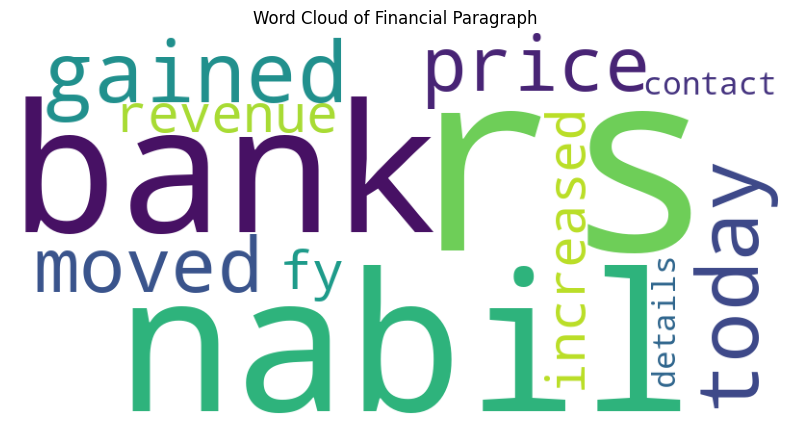

In [ ]:
# Full pipeline example
text = sample_texts["finance_text"]

text = to_lowercase(text)
text = remove_urls(text)
text = remove_emails(text)
text = remove_special_characters(text)
text = remove_extra_spaces(text)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.title('Word Cloud of Financial Paragraph')
plt.imshow(wordcloud)
plt.axis('off')
plt.savefig('wordcloud.png')
plt.show()